<div style="float: right;">
  <a href="../de/bias_further.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/bias_further.html">English</a>
</div>

# 3. More Biases: Survivorship and P-hacking

The previous two chapters focused on omitted variable bias and sampling bias in detail.
Bias, however, takes many more forms. This chapter gives a brief demonstration of
two further biases that appear frequently in research. Both section shows a compact, concrete example so
you can recognise the pattern in your own work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Helper ─────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    """Average prediction error in $/hr (lower = better)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ══════════════════════════════════════════════════════════════════════════
# Dataset 1: Survivorship bias
# ══════════════════════════════════════════════════════════════════════════
n1 = 3000
tenure_raw  = np.random.exponential(6, n1).clip(0.1, 30)
edu_s       = np.random.normal(14, 2.5, n1).clip(8, 20).round().astype(int)
exp_s       = np.random.normal(10, 5,   n1).clip(0, 30)
hours_s     = np.random.normal(40, 8,   n1).clip(20, 60)

wage_s = (
    5.0
    + 0.5  * edu_s
    + 0.3  * exp_s
    + 0.35 * tenure_raw
    + 0.08 * hours_s
    + np.random.normal(0, 2.5, n1)
).clip(10, None)

df_s = pd.DataFrame({
    'tenure':         tenure_raw,
    'education':      edu_s,
    'experience':     exp_s,
    'hours_per_week': hours_s,
    'wage':           wage_s,
})

# Workers with short tenure AND below-median wages are likely to have left:
# they found a better job, were let go, or simply are not in the company archive.
wage_40th  = np.percentile(wage_s, 40)
leave_prob = np.where(
    (tenure_raw < 3) & (wage_s < wage_40th),
    0.80,   # 80% of this group are absent from the archive
    0.08    # 8% baseline for everyone else
)
survived = np.random.binomial(1, 1 - leave_prob, n1).astype(bool)

df_surv_full    = df_s.copy()            # the true population
df_surv_archive = df_s[survived].copy()  # what the archive actually contains

# ══════════════════════════════════════════════════════════════════════════
# Dataset 2: P-hacking
# ══════════════════════════════════════════════════════════════════════════
n2 = 5000
edu_p  = np.random.normal(14, 2.5, n2).clip(8, 20).round().astype(int)
exp_p  = np.random.normal(10, 5,   n2).clip(0, 30)

# 20 completely random yes/no attributes. None have any real effect on wages
FEATURE_NAMES = [
    'Born in odd month',   'First name < 5 letters', 'Owns a pet',
    'Left-handed',         'Has a middle name',       'Born on a weekend',
    'Drives to work',      'Prefers tea over coffee', 'Has siblings',
    'Plays an instrument', 'Uses public transport',   'Has a garden',
    'Reads fiction',       'Wears glasses',           'Has a tattoo',
    'Likes spicy food',    'Morning person',          'Keeps a diary',
    'Prefers mountains',   'Owns a bicycle',
]
random_features = np.random.randint(0, 2, size=(n2, len(FEATURE_NAMES)))

wage_p = (
    5.0
    + 0.5 * edu_p
    + 0.3 * exp_p
    + 0.2 * random_features[:,-1]
    + np.random.normal(0, 3, n2)
).clip(10, None)
df_p = pd.DataFrame(random_features, columns=FEATURE_NAMES)
df_p['wage'] = wage_p

# ══════════════════════════════════════════════════════════════════════════
# Dataset 3: Selection bias (education drives enrolment)
# ══════════════════════════════════════════════════════════════════════════
n3 = 1000
edu_sel = np.random.normal(13, 3, n3).clip(8, 20).round().astype(int)
exp_sel = np.random.normal(8,  5, n3).clip(0, 30)

# Highly educated people are much more likely to sign up for the programme
raw_logit   = -1.5 + 0.20 * (edu_sel - 8)       # increases with education
enroll_prob = 1 / (1 + np.exp(-raw_logit))        # sigmoid → keeps values in (0, 1)
enrolled    = np.random.binomial(1, enroll_prob, n3).astype(bool)

TRUE_EFFECT = 0.50   # the programme's real effect is just $0.50/hr

wage_sel = (
    5.0
    + 0.70 * edu_sel
    + 0.25 * exp_sel
    + TRUE_EFFECT * enrolled          # small genuine effect
    + np.random.normal(0, 2, n3)
).clip(10, None)

EDU_LABELS = ['Low (≤12 yrs)', 'Medium (13–15 yrs)', 'High (≥16 yrs)']
df_sel = pd.DataFrame({
    'education':  edu_sel,
    'experience': exp_sel,
    'enrolled':   enrolled.astype(int),
    'wage':       wage_sel,
})
df_sel['edu_group'] = pd.cut(
    df_sel['education'],
    bins=[0, 12, 15, 20],
    labels=EDU_LABELS
)

---

## Part 1: Survivorship Bias

### What is it?

Imagine studying what makes a restaurant successful by visiting only restaurants
that are *still open*. Every restaurant in your sample has survived, meaning it
already passed some invisible filter. The restaurants that failed (and might have
shared many features with your successful ones) simply are not there to be studied.
Your conclusions about "success factors" are shaped entirely by that invisible filter.

This is **survivorship bias**: when your data only contains records of entities
that made it through some selection process, while the "non-survivors" are silently
excluded. The result is a dataset that looks more successful, more capable, or more
extreme than the true underlying population. The survivorship bias is thus a special
case of the sampling bias, that arises when the sampling process is influenced by 
the outcome of interest.

### In a wage archive

Our synthetic dataset simulates a company HR archive. Workers with short tenure
**and** below-median wages are far more likely to have already left as they found
better-paying jobs elsewhere or were let go. The archive contains only the workers
who stayed. The chart below shows how this filter distorts the distribution of
short-tenure employees.

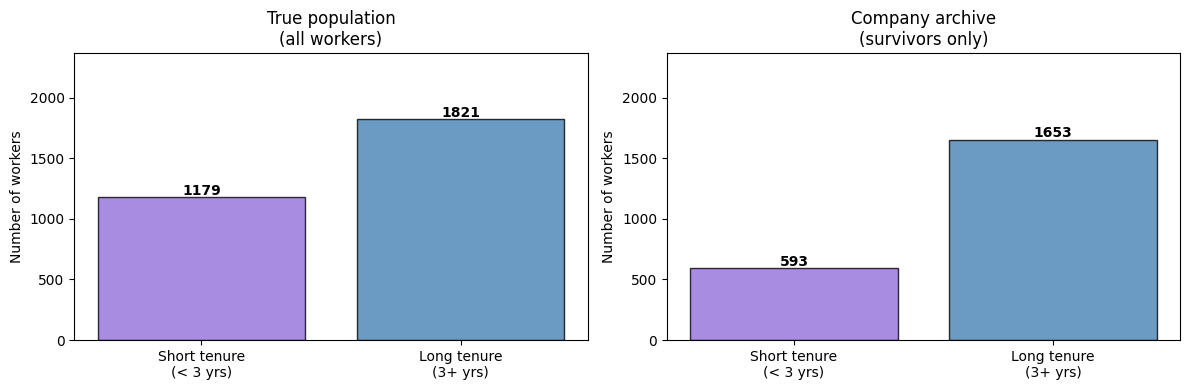

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df_plot, title in [
    (axes[0], df_surv_full,    'True population\n(all workers)'),
    (axes[1], df_surv_archive, 'Company archive\n(survivors only)'),
]:
    n_short = (df_plot['tenure'] < 3).sum()
    n_long  = (df_plot['tenure'] >= 3).sum()
    ax.bar(['Short tenure\n(< 3 yrs)', 'Long tenure\n(3+ yrs)'],
           [n_short, n_long],
           color=['mediumpurple', 'steelblue'], edgecolor='black', alpha=0.8)
    ax.set_ylabel('Number of workers')
    ax.set_title(title)
    ax.set_ylim(0, (df_surv_full['tenure'] >= 3).sum() * 1.3)
    for i, v in enumerate([n_short, n_long]):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The archive has far fewer short-tenure workers than the true population because
most of the low-wage, short-tenure employees have already left. A model trained
only on archive data will have rarely seen this group and will get their wages
systematically wrong.

In [3]:
feature_cols_s = ['tenure', 'education', 'experience', 'hours_per_week']

# Train the model exclusively on the archive (survivors)
X_archive = df_surv_archive[feature_cols_s].values
y_archive  = df_surv_archive['wage'].values

# Test on the full population including the workers who would have left
X_full = df_surv_full[feature_cols_s].values
y_full = df_surv_full['wage'].values
tenure_full_arr = df_surv_full['tenure'].values

lr_surv = LinearRegression()
lr_surv.fit(X_archive, y_archive)        # learn from survivors only
y_pred_surv = lr_surv.predict(X_full)    # predict for everyone

short_mask_s = tenure_full_arr < 3
long_mask_s  = tenure_full_arr >= 3

print("Model trained on archive (survivors only)")
print("=" * 60)
print(f"  Short tenure (< 3 yrs): RMSE = "
      f"{rmse(y_full[short_mask_s], y_pred_surv[short_mask_s]):.2f} $/hr  "
      f"(n = {short_mask_s.sum()})")
print(f"  Long tenure  (3+ yrs):  RMSE = "
      f"{rmse(y_full[long_mask_s],  y_pred_surv[long_mask_s]):.2f} $/hr  "
      f"(n = {long_mask_s.sum()})")
print()
print("The short-tenure group, mostly absent from training data, has a much")
print("higher error. The model has never seen most of their low-wage records.")

Model trained on archive (survivors only)
  Short tenure (< 3 yrs): RMSE = 2.67 $/hr  (n = 1179)
  Long tenure  (3+ yrs):  RMSE = 2.49 $/hr  (n = 1821)

The short-tenure group, mostly absent from training data, has a much
higher error. The model has never seen most of their low-wage records.


**Key insight:** If you train a model on data that has already passed a selection
filter (still-active companies, published studies, surviving projects), the model
will perform poorly on the cases that *did not* survive, often precisely the cases
where you most need reliable predictions.

---

## Part 2: P-hacking

### What is it?

Suppose you want to know whether carrying a lucky charm improves exam results.
You test 20 different charms: a rabbit foot, a four-leaf clover, a blue pen, and
so on. Even if none of them has any real effect, roughly **1 in 20** tests will
appear "statistically significant" just by chance (this is what a significance
threshold of 5 % actually means). If you then publish *only* that one result
"blue pens improve exam scores!", you have committed **p-hacking**: cherry-picking
a significant result from a large pool of tests, while discarding all the
non-significant ones.

P-hacking can happen accidentally (a researcher genuinely tests many things and
reports the "interesting" result) or deliberately. Either way, it inflates the
number of false findings in the scientific literature.

### In a wage study

We generate wages based only on education and experience. Then we invent **20
completely random yes/no attributes** for each worker: things like "owns a pet"
or "prefers mountains" that have absolutely no relationship to wages. We then
test each attribute for a wage effect using a t-test (which asks: "do workers with
this attribute earn significantly differently from those without it?").

In [4]:
# Run a t-test for each random feature: does having it predict higher wages?
# (None of these features have any real effect, they are pure noise.)
p_values = []
for feat in FEATURE_NAMES:
    wages_yes = df_p.loc[df_p[feat] == 1, 'wage']
    wages_no  = df_p.loc[df_p[feat] == 0, 'wage']
    _, p = stats.ttest_ind(wages_yes, wages_no)
    p_values.append(p)

results_p = (pd.DataFrame({'Feature': FEATURE_NAMES, 'p-value': p_values})
               .sort_values('p-value')
               .reset_index(drop=True))

print("T-test results for 20 random features  (none are real wage predictors)")
print("=" * 60)
for _, row in results_p.iterrows():
    flag = "  ← SIGNIFICANT (p < 0.05)" if row['p-value'] < 0.05 else ""
    print(f"  {row['Feature']:<28}: p = {row['p-value']:.3f}{flag}")

n_sig = (results_p['p-value'] < 0.05).sum()
print(f"\n{n_sig} out of 20 tests appear 'significant' at p < 0.05")
print(f"Expected by chance alone: 20 × 0.05 = 1.0")

T-test results for 20 random features  (none are real wage predictors)
  Owns a bicycle              : p = 0.024  ← SIGNIFICANT (p < 0.05)
  Born in odd month           : p = 0.091
  Has a tattoo                : p = 0.111
  Prefers tea over coffee     : p = 0.140
  Uses public transport       : p = 0.155
  Plays an instrument         : p = 0.160
  Has siblings                : p = 0.267
  Born on a weekend           : p = 0.321
  Keeps a diary               : p = 0.342
  Reads fiction               : p = 0.380
  Drives to work              : p = 0.381
  First name < 5 letters      : p = 0.439
  Has a middle name           : p = 0.528
  Likes spicy food            : p = 0.534
  Left-handed                 : p = 0.554
  Prefers mountains           : p = 0.583
  Has a garden                : p = 0.628
  Wears glasses               : p = 0.658
  Owns a pet                  : p = 0.819
  Morning person              : p = 0.934

1 out of 20 tests appear 'significant' at p < 0.05
Expected by

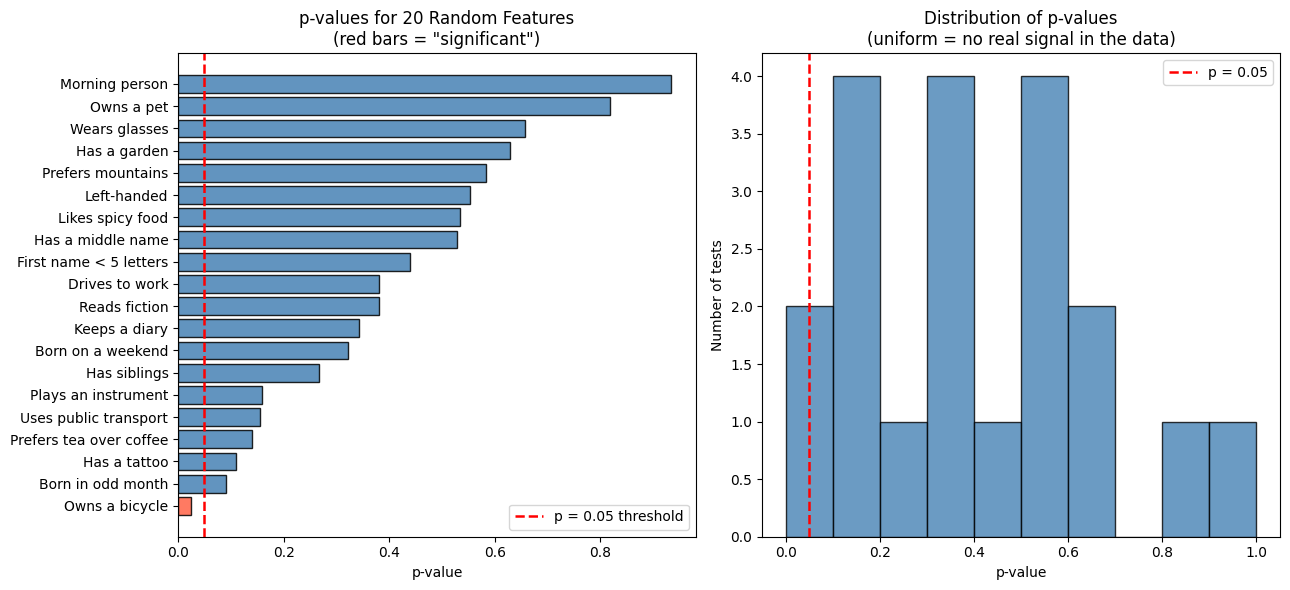

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: horizontal bar chart of all p-values
bar_colors = ['tomato' if p < 0.05 else 'steelblue'
              for p in results_p['p-value']]
axes[0].barh(results_p['Feature'], results_p['p-value'],
             color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1.8,
                label='p = 0.05 threshold')
axes[0].set_xlabel('p-value')
axes[0].set_title('p-values for 20 Random Features\n(red bars = "significant")')
axes[0].legend()

# Right: histogram of p-values. Should be roughly uniform under the null
axes[1].hist(p_values, bins=10, range=(0, 1),
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0.05, color='red', linestyle='--', linewidth=1.8,
                label='p = 0.05')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('Number of tests')
axes[1].set_title('Distribution of p-values\n(uniform = no real signal in the data)')
axes[1].legend()

plt.tight_layout()
plt.show()

The histogram on the right is the key diagnostic: when there is truly no effect,
p-values are spread roughly uniformly between 0 and 1. Only a small cluster at the
left edge (below 0.05) represents the "false positives" that chance produces. If
a researcher reports only those, the published literature would contain a misleading
result about wages.

p-hacking can have many different forms and might happen either accidentally or deliberately. For example:
- Researchers might run non-deterministic algorithms (like random forests) multiple times and report only the best result.
- They might test many different model specifications (adding or removing features) and report only the one that yields a significant result.
- They might also consider certain data points "outliers" and exclude them from the analysis, which can influence the results.

**Key insight:** p-hacking bias arises when one receives a significant result from a test using either accidental or deliberate cherry-picking. One might manipulate the data, the model, or keep testing different hypotheses until a significant result is found. Transparent reporting of all tests, and corrections for multiple comparisons (such as the Bonferroni correction), are the standard remedies for good scientific procedures.

## Summary

| Bias | What goes wrong                                       | How to spot it                                                             |
|---|-------------------------------------------------------|----------------------------------------------------------------------------|
| **Survivorship** | Data only records "successes"; failures are invisible | Ask: who is *not* in this dataset, and why?                                |
| **P-hacking** | Tests are manipulated to receive significant results  | Always report all results and ask: was I really unbiased in this analysis? |